<a href="https://colab.research.google.com/github/Mariagiusi23/ID-001-AWOL-for-Audio/blob/main/notebook/01_BaselineClapEmbeddingToFmSynthesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🎧 Setup & Reproducibility**

In [1]:
import os, random, numpy as np, torch

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device, "| Torch:", torch.__version__)


✅ Device: cpu | Torch: 2.6.0+cu124


#**🎯 STEP 1 — From Text to Embedding with CLAP**

**📍 1.1 — Load CLAP Model and Processor**

In [4]:
from transformers import AutoProcessor, ClapModel

clap_id = "laion/clap-htsat-unfused"
processor = AutoProcessor.from_pretrained(clap_id)
clap_model = ClapModel.from_pretrained(clap_id).to(device).eval()

**📍 1.2 — Encode Prompt into CLAP Embedding**

In [5]:
prompt = "a soft metallic ringing"

with torch.no_grad():
    inputs = processor(text=prompt, return_tensors="pt", padding=True).to(device)
    text_feat = clap_model.get_text_features(**inputs)   # [1, 512]
    text_feat = torch.nn.functional.normalize(text_feat, dim=-1)

print("✅ Text embedding shape:", tuple(text_feat.shape))

✅ Text embedding shape: (1, 512)


#**🎯 STEP 2 — Mapping Embeddings to Audio**

**📍 2.1 — FM Synthesizer Function**

In [6]:
import numpy as np

def synthesize(params, sr=16000, duration=1.0):
    """
    params = [carrier_freq (Hz), modulator_freq (Hz), modulation_index, amplitude]
    """
    cf, mf, mi, amp = params
    t = np.linspace(0, duration, int(sr*duration), endpoint=False)

    # FM synthesis
    mod = np.sin(2 * np.pi * mf * t)
    y = amp * np.sin(2 * np.pi * cf * t + mi * mod)

    # Anti-click: 10 ms fade-in/out
    fade = int(0.01 * sr)
    if fade > 0:
        w = np.linspace(0, 1, fade)
        y[:fade] *= w
        y[-fade:] *= w[::-1]

    # Safety normalization
    peak = np.max(np.abs(y)) + 1e-8
    if peak > 1:
        y = y / peak

    return y.astype(np.float32)

**📍 2.2 — MLP Baseline (Untrained)**

In [7]:
# 📍 Define the MLP baseline model (UNTRAINED)
class MLP(torch.nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, output_dim=4):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# 📍 Instantiate the MLP baseline
mlp = MLP().to(device).eval()   # ⚠️ UNTRAINED baseline

# (Optional) save untrained weights
torch.save(mlp.state_dict(), "mlp_baseline_model.pt")
print("✅ MLP baseline model initialized (untrained) and saved.")

✅ MLP baseline model initialized (untrained) and saved.


**📍 2.3 — Mapping to Safe Parameter Ranges**

In [8]:
def map_to_ranges(raw4: torch.Tensor):
    """
    raw4: torch tensor [1,4] unbounded
    returns: np.array([carrier, modulator, index, amp]) in safe ranges
    """
    x = torch.tanh(raw4).squeeze(0).detach().cpu().numpy()  # [-1,1]
    to_range = lambda v, lo, hi: lo + (v+1)*0.5*(hi-lo)
    return np.array([
        to_range(x[0],  80.0, 1200.0),  # carrier Hz
        to_range(x[1],  20.0, 1200.0),  # modulator Hz
        to_range(x[2],   0.0,    5.0),  # index
        to_range(x[3],  0.25,   0.9),   # amplitude
    ], dtype=np.float32)

from IPython.display import Audio, display

@torch.no_grad()
def generate_audio_from_prompt(prompt, sr=16000, duration=1.5):
    inputs = processor(text=prompt, return_tensors="pt", padding=True).to(device)
    z = clap_model.get_text_features(**inputs)
    z = torch.nn.functional.normalize(z, dim=-1)

    raw = mlp(z)
    params = map_to_ranges(raw)

    y = synthesize(params, sr=sr, duration=duration)
    return params, y


**📍 2.4 — Usage examples**


🎧 Prompt: a soft metallic ringing
➡️ Params [carrier, modulator, index, amp]: [6.16007e+02 6.10532e+02 2.54100e+00 5.84000e-01]


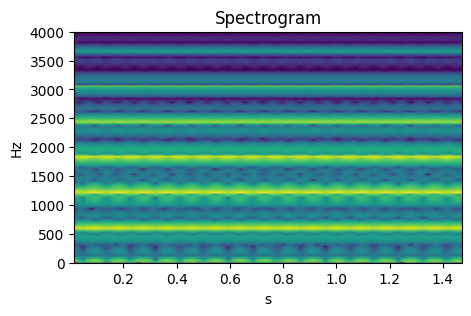


🎧 Prompt: a deep hollow drone
➡️ Params [carrier, modulator, index, amp]: [6.14764e+02 6.09848e+02 2.54200e+00 5.84000e-01]


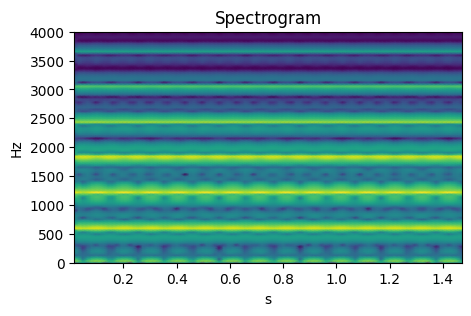


🎧 Prompt: a bright buzzy tone
➡️ Params [carrier, modulator, index, amp]: [6.19172e+02 6.11681e+02 2.53600e+00 5.84000e-01]


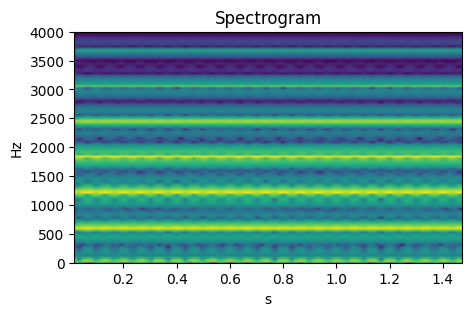

In [9]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

prompts = [
    "a soft metallic ringing",
    "a deep hollow drone",
    "a bright buzzy tone",
]

sr = 16000
duration = 1.5

for p in prompts:
    params, y = generate_audio_from_prompt(p, sr=sr, duration=duration)
    print(f"\n🎧 Prompt: {p}")
    print("➡️ Params [carrier, modulator, index, amp]:", np.round(params, 3))
    display(Audio(y, rate=sr))

    f, t, Sxx = spectrogram(y, fs=sr, nperseg=512, noverlap=256)
    plt.figure(figsize=(5,3))
    plt.pcolormesh(t, f, 10*np.log10(Sxx + 1e-10), shading='gouraud')
    plt.title("Spectrogram"); plt.ylabel("Hz"); plt.xlabel("s")
    plt.ylim(0, 4000); plt.show()

**📍 2.5 — Save Outputs**

In [10]:
import soundfile as sf, os
os.makedirs("outputs_nb01", exist_ok=True)

for p in prompts:
    params, y = generate_audio_from_prompt(p, sr=sr, duration=duration)
    base = p.replace(" ", "_")
    sf.write(f"outputs_nb01/{base}.wav", y, sr)
    np.save(f"outputs_nb01/{base}_params.npy", params)

print("✅ Saved to outputs_nb01/")

✅ Saved to outputs_nb01/


# **📌 Final comment**

In this notebook I implemented a **baseline pipeline** that maps
a text prompt into sound using CLAP embeddings and a simple untrained MLP.  
The model does not learn any meaningful mapping yet, but it allows me to:

- Verify the integration between **CLAP** and my **FM synthesizer**.
- Produce initial audio samples and visualize their spectrograms.
- Save outputs that I will compare against trained models in the next notebooks.

This baseline represents my **starting point**:  
in the following notebooks I will train the mapping (MLP and RealNVP)
to obtain more coherent and controllable audio synthesis.